## Daniel Peña Fonseca. Civic registration number: 20031020-T330

Use of LLMs (ChatGPT) for this exercise:
- Common use of LLM: Used for most exercises for debugging and to do plots faster.
- Exercise 1.1: No Use of LLMs apart from faster plotting.
- Exercise 1.2: Used to apply the Nelder-Mead approach in scipy.optimize.minimize.
- Exercise 1.3: Used to do the plots faster and for the following line: pacf_values = pacf(training_data, nlags=max_p, method="ywadjusted").
- Exercise 1.4: Used to familiarize with the way in which tensorflow works; i.e. Sequential, ModelCheckpoint, load_model, lstm.fit, and for this type of rearrangements x_training = x_training[..., np.newaxis].
- Exercise 1.5: It was used to double check my conclusions about the coefficients obtained and to plot faster.

# Exercise 1

In [4]:
%pip install -q tensorflow statsmodels

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import math
from matplotlib import pyplot as plt
import scipy.optimize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import statistics
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from statsmodels.tsa.stattools import pacf

# Exercise 1.1

In this exercise we open the data files and store it in variables that will be used for the next exercises. We store training, validation and test data in different variables and we plot them separately.

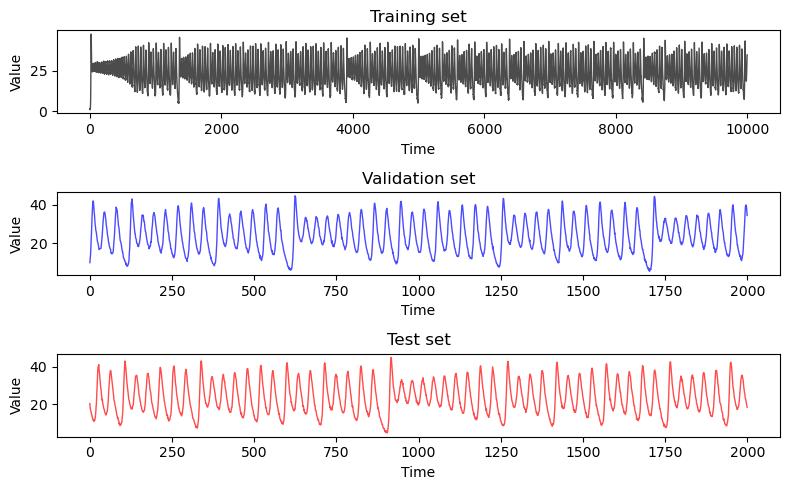

In [6]:
filename = 'Assignment_1/A1_test.txt'
training_data = []
validation_data = []
test_data = []

# Reading and saving training set
filename = 'Assignment_1/A1_training.txt'
with open(filename, 'r') as file_object:
    training_lines = file_object.readlines()

for line in training_lines:
    number = float(line.strip())
    training_data.append(number)


# Reading and saving validation set
filename = 'Assignment_1/A1_validation.txt'
with open(filename, 'r') as file_object:
    validation_lines = file_object.readlines()

for line in validation_lines:
    number = float(line.strip())
    validation_data.append(number)


# Reading and saving test set
filename = 'Assignment_1/A1_test.txt'
with open(filename, 'r') as file_object:
    test_lines = file_object.readlines()

for line in test_lines:
    number = float(line.strip())
    test_data.append(number)

time_in_training_data = [value for value in range(0,len(training_data))]
time_in_validation_data = [value for value in range(0,len(validation_data))]
time_in_test_data = [value for value in range(0,len(test_data))]


# Plotting
fig, axes = plt.subplots(3, 1, figsize=(8, 5))

axes[0].plot(time_in_training_data, training_data,
             color='k', linewidth=1, alpha=0.7)
axes[0].set_title("Training set")
axes[0].set_ylabel( "Value")
axes[0].set_xlabel("Time")

axes[1].plot(time_in_validation_data, validation_data, color='b', linewidth=1, alpha=0.7)
axes[1].set_title("Validation set")
axes[1].set_ylabel( "Value")
axes[1].set_xlabel("Time")

axes[2].plot(time_in_test_data, test_data, color='r', linewidth=1, alpha=0.7)
axes[2].set_title("Test set")
axes[2].set_xlabel("Time")
axes[2].set_ylabel( "Value")

plt.tight_layout()
plt.show()




# Exercise 1.2

## ARMA Model introduction
For a time series, we define the value taken by the magnitude at time $t$ as $y_{t}$. Using the ARMA model, we seek to predict the value that the series will take at time $t$ following:
$$\hat{y}_{t}=c+\phi_{1}y_{t-1}+...+\phi_{p}y_{t-p}+\theta_{1}\epsilon_{t-1}+...+\theta_{q}\epsilon_{t-q}+\theta_{t}$$
The terms $\phi_{i}$ with $i=1,...,p$ and $\theta_{j}$ with $j=1,...,q$ are called the coefficients. The terms $\phi_{i}$ with $i=1,...,p$ are called value coefficients, since they are paired with the previous values $y_{t-1},...,y_{t-p}$; while terms $\theta_{j}$ with $j=1,...,q$ are called error cofficients, since they are paired with the previous errors $\epsilon_{t-1},...,\epsilon_{t-q}$.

## Log likelihood
These coefficients (and $c$) are calculated by fitting the ARMA model to the training time series. Since we want to make the prediction as accurate as possible, we want to minimize the prediction errors $\epsilon_{t}$, and the variance of these errors, since it is not enough with minimizing one-time error, we want to avoid a wide error distribution. Therefore, we want to ensure a small mean and a small variance when analyzing the error distribution.
Fitting the ARMA model to the training time series consists on finding the coefficients for which the predicted time series exhibits the maximum log-likelihood.

The log likelihood is defined as $l(\phi,\theta,\sigma^{2})$:
$$l(\phi,\theta,\sigma^{2})=-\underbrace{\frac{n}{2}\ln(2\pi)}_{A}-\underbrace{\frac{n}{2}\ln(\sigma^{2})}_{B}-\underbrace{\frac{1}{2\sigma^{2}}\sum_{t=1}^n\epsilon^2_{t}}_{C}$$
Analyzing this expression, one can see that when we look for the maximum of the function, we are looking for $\sigma^{2}=\frac{1}{n}\sum_{t=1}^{n}\epsilon^{2}_{t}$. Since $\sigma^{2}\equiv\frac{1}{n}\sum_{t=1}^{n}(\epsilon_{t}-\mu)^{2}$, where $\mu$ is the average of the error set, the minimum is obtained for $\mu=0$; i.e. an error distribution for a zero average. This analysis is computed studying the maximum of $f(a,b)=-\frac{n}{2}\ln(a^2)-\frac{1}{2a^2}b$, where we find that the maximum corresponds to $a^2=b/n$ (calculation details not presented here).

In the maximum, we can define $\sigma^{2} = \frac{1}{n}\sum_{t=1}^n\epsilon^2_{t}\equiv \frac{a}{n}$.

$$l=-\frac{n}{2}\ln(2\pi)-\frac{n}{2}\ln(a/n)-\frac{1}{2a/n}a=-\frac{n}{2}\ln(2\pi)-\frac{n}{2}\ln(a/n)-\frac{n}{2} \propto -\ln(a)$$

The maximum value will appear for $a=0^{+}$. Thus, the maximum likelihood will be obtained for a model where the error distribution has zero mean, and where $\sum_{t=1}^n\epsilon^2_{t}=0^{+}$. This looks reasonable: mean-zero implies that the predictions are not biased towards positive errors ($\mu>0$) nor negative errors ($\mu<0$); we want a distribution with as few error as possible: $\mu=0$. However, we need more than $\frac{1}{n}\sum_{t=1}^n\epsilon_{t}=0$; we also need $\sum_{t=1}^n\epsilon^2_{t}=0^{+}$; i.e. zero-variance. A zero-mean distribution could appear for highly positive and highly negative errors; however, with a zero-variance, we ensure small errors $\epsilon^{2}_{t}\to 0$  $\forall t$.

After this study, it seems reasonable that the fitting of the ARMA model is done by maximizing the log likelihood.


## RMSE and prediction function
After fitting the ARMA model, we measure the accuracy of the prediction by calculating the RMSE. For a set of $n$ values, where each has a real value $y_t$ and a predicted value of $\hat{y}_{t}$, with $i=1,...,n$, the RMSE is defined as follows:
$$ \text{RMSE}=\sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t-\hat{y}_{t})^{2}} $$

The function used to predict the next value considers all possible cases:
- The predicted value is the first in the time series, so no previous values or errors can be used.
- The prediction only uses some of the coefficients.
- The prediction uses all the coefficients.

Note: For Exercise 1.2, arbitrary values for $p$ and $q$ where chosen.



The prediction of the test set has an RMSE of 1.2465


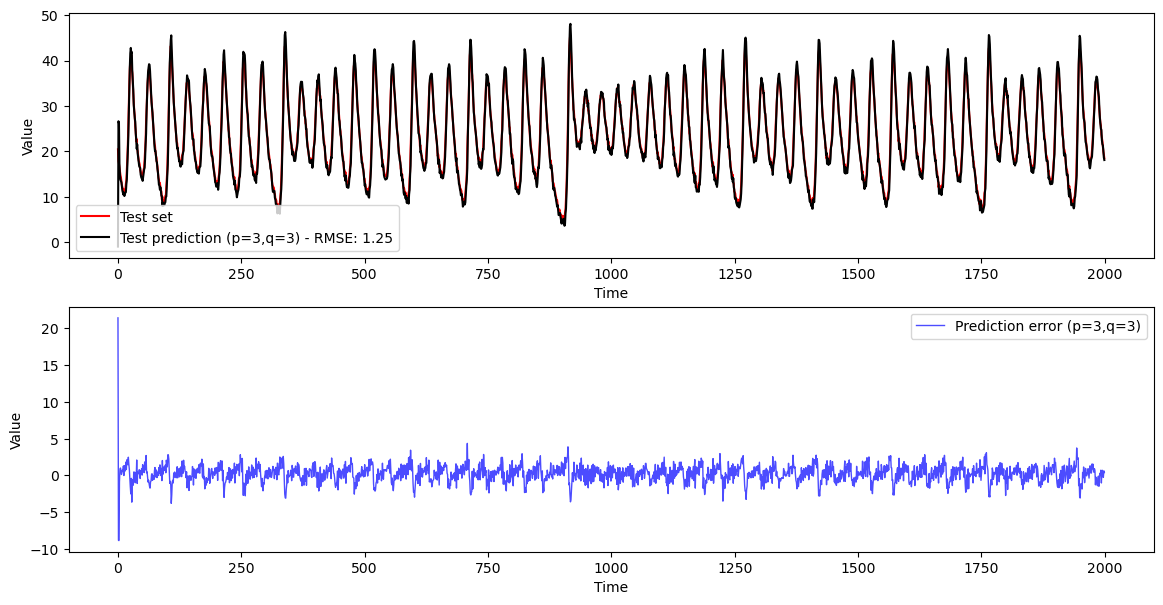

In [7]:

def rmse(real_values, predicted_values):
    "This function calculates the RMSE"
    number_of_values = len(real_values)
    sum_term = 0
    for i in range(number_of_values):
        real_value = real_values[i]
        predicted_value = predicted_values[i]
        new_term = (predicted_value - real_value)**2
        sum_term += new_term

    rmse_value = math.sqrt(sum_term/number_of_values)

    return rmse_value


def predict_next_value(i, p, q, real_values, error_values, previous_values_coefficients, previous_errors_coefficients, intercept):
    "This function uses the last p values, and the last q errors of the time series to predict the next value in the time series."

    predicted_value = 0

    if i==0:
        predicted_value = intercept


    elif (i < p) and (i < q):
        used_values = real_values[0:i]
        used_errors = error_values[0:i]

        used_values_coefficients = previous_values_coefficients[-i:]
        used_errors_coefficients = previous_errors_coefficients[-i:]

        for value, coefficient in zip(used_values, used_values_coefficients):
            predicted_value += value*coefficient

        for error, coefficient in zip(used_errors, used_errors_coefficients):
            predicted_value += error*coefficient

        predicted_value += intercept


    elif (i >= p) and (i < q):
        used_values = real_values[i-p:i]
        used_errors = error_values[0:i]

        used_values_coefficients = previous_values_coefficients[-p:]
        used_errors_coefficients = previous_errors_coefficients[-i:]

        for value, coefficient in zip(used_values, used_values_coefficients):
            predicted_value += value*coefficient

        for error, coefficient in zip(used_errors, used_errors_coefficients):
            predicted_value += error*coefficient

        predicted_value += intercept


    elif (i < p) and (i >= q):
        used_values = real_values[0:i]
        used_errors = error_values[i-q:i]

        used_values_coefficients = previous_values_coefficients[-i:]
        used_errors_coefficients = previous_errors_coefficients[-q:]

        for value, coefficient in zip(used_values, used_values_coefficients):
            predicted_value += value*coefficient

        for error, coefficient in zip(used_errors, used_errors_coefficients):
            predicted_value += error*coefficient

        predicted_value += intercept


    elif (i >= p) and (i >= q):
        used_values = real_values[i-p:i]
        used_errors = error_values[i-q:i]

        used_values_coefficients = previous_values_coefficients[-p:]
        used_errors_coefficients = previous_errors_coefficients[-q:]

        for value, coefficient in zip(used_values, used_values_coefficients):
            predicted_value += value*coefficient

        for error, coefficient in zip(used_errors, used_errors_coefficients):
            predicted_value += error*coefficient

        predicted_value += intercept

    return predicted_value


def calculate_whole_prediction_error(real_values, previous_values_coefficients, previous_errors_coefficients, intercept, p, q):
    "This function calculates the all the errors in the prediction"
    
    error_values = []

    for i in range(len(real_values)):
        real_value = real_values[i]
        predicted_value = predict_next_value(i, p, q, real_values, error_values, previous_values_coefficients, previous_errors_coefficients, intercept)
        
        current_error = real_value - predicted_value

        error_values.append(current_error)

    return error_values


def log_likelihood(real_values, previous_values_coefficients, previous_errors_coefficients, intercept, p, q):
    errors = calculate_whole_prediction_error(real_values, previous_values_coefficients, previous_errors_coefficients, intercept, p, q)
    errors_squared = np.array(errors)**2
    time_length = len(real_values)

    eps_variance = np.var(errors)

    term_1 = -(time_length/2)*np.log(2*np.pi)
    term_2 = -(time_length/2)*np.log(eps_variance)
    term_3 = -((1)/(2*eps_variance))*np.sum(errors_squared)

    log_likelihood_value = term_1 + term_2 + term_3

    return log_likelihood_value


def function_for_minimizing(coefficients, training_data):
    # The first p coefficients will be associated to the previous values; the rest to the errors
    previous_values_coefficients = coefficients[:p]
    previous_errors_coefficients = coefficients[p:p+q]
    intercept = coefficients[p+q]

    real_values = training_data
    log_likelihood_value = log_likelihood(real_values, previous_values_coefficients, previous_errors_coefficients, intercept, p, q)

    # We want to maximize the log_likelihood. I.e. minimize -log_likelihood
    return -log_likelihood_value

p = 3
q = 3
# We use scipy.optimize to find the coefficients
res = scipy.optimize.minimize(function_for_minimizing, np.zeros(p+q+1), training_data, method = 'Nelder-Mead', tol=1e-4)
coefficients = res['x']

real_test_values = np.array(test_data)
previous_values_coefficients = coefficients[:p]
previous_errors_coefficients = coefficients[p:p+q]
intercept = coefficients[p+q]
# mu = np.mean(training_data) # We determine the intercept value using the training data and the value coefficients
# intercept = mu * (1 - np.sum(previous_values_coefficients))

errors_test = np.array(calculate_whole_prediction_error(real_test_values, previous_values_coefficients, previous_errors_coefficients, intercept, p, q))
predicted_test_values = real_test_values - errors_test

# Plotting
rmse_test = rmse(real_test_values, predicted_test_values)
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(time_in_test_data, test_data,
             color='r', label = 'Test set')
axes[0].plot(time_in_test_data, predicted_test_values,
             color='k', label = f'Test prediction (p={p},q={q}) - RMSE: {rmse_test:.2f}')
axes[0].set_ylabel( "Value")
axes[0].set_xlabel("Time")
axes[0].legend()

axes[1].plot(time_in_test_data, errors_test,
             color='b', linewidth=1, alpha=0.7, label = f'Prediction error (p={p},q={q})')
axes[1].set_ylabel( "Value")
axes[1].set_xlabel("Time")
axes[1].legend()

print('\n')
print(f'The prediction of the test set has an RMSE of {rmse_test:.4f}')

# Exercise 1.3

For the following exercise, we compute the autocorrelation function (ACF) and the partial autocorrelation function (PACF). 
## Autocorrelation function (ACF)
The value that the autocorrelation function takes after $k$ lags is defined as $\rho_{k}$:
$$\rho_{k}=\frac{\gamma_{k}}{\gamma_{0}}=\frac{\sum_{t=k+1}^{T}(y_{t}-\bar{y})(y_{t-k}-\bar{y})}{\sum_{t=1}^{T}(y_{t}-\bar{y})^{2}}$$

Analyzing the expression we can see that the denominator is $N\cdot \sigma^{2}$, with $\sigma^{2}$ being the variance. The denominator will guarantee that the ACF stays between -1 and 1 no matter what the time series looks like.

The numerator studies how correlated is the fact that the time series took a certain value $k$ steps ago with the time series taking a certain value in the current time step. Since we substract the average in each term of the product, if the product is positive, it implies that when $y_{t-k}$ is positive, $y_{t}$ is positive; and when $y_{t-k}$ is negative, $y_{t}$ is negative; i.e. positive correlation. If the product is negative, when $y_{t-k}$ is positive, $y_{t}$ is negative; and when $y_{t-k}$ is negative, $y_{t}$ is positive; i.e. negative correlation.
If the behavior is consistent, the sum of the products will be significantly positive (positive correlation) or significantly negative (negative correlation). Otherwise, the sum will be $\approx 0$.

We are interested in keeping the last $k$ values for which we can consistently guarantee that there is noticeable correlation between the lagged value and the current value.

With this in mind, we compute the autocorrelation function for the training data, and we try to observe what value of $q$ shows a cutoff; i.e. the value of $q$ after which the correlation is $\approx 0$ because no correlation exists.

Observing the figure presented afterwards, we see a gradual decrease in the ACF, showing that we cannot infer a reasonable value of $q$, since there is no cutoff. With this behavior, it does not seem like using moving average will benefit the prediction, so we could keep $q=0$ or $q=1$ if we had to choose, and study the PACF to study the Autorregresive model AR(p) and determine the best performing $p$.

With the reasoning behind ACF, we can see that with ACF we study the question 'If $k$ steps ago we had a certain value, how does that propagate in time to the present?'. This is why ACF gives the value $q$ that we should use for the moving average part of ARMA: $MA(q)$ when we have a clear cutoff.

## Partial autocorrelation function (PACF)
The PACF is more direct than the ACF, since it simply studies the question 'If $k$ steps ago the time series had a value, without taking into account the propagation of it, how useful is it to consider its value?'.

With an AR(k) model we have:
$$y_{t}=\phi_{k1}y_{t-1}+\phi_{k2}y_{t-2}+...+\phi_{kk}y_{t-k}+\epsilon_{t}$$

Since the PACF is $\phi_{kk}$, we will compute PACF(k) and keep the value $k=p$ for which we get a cutoff. We do this because we only want to use the 'useful' values for prediction; i.e. those where $\phi_{pp}$ is significantly different than 0.

For the figure shown afterwards, we can choose $p=3$, since PACF($p=4$) is already a small value.


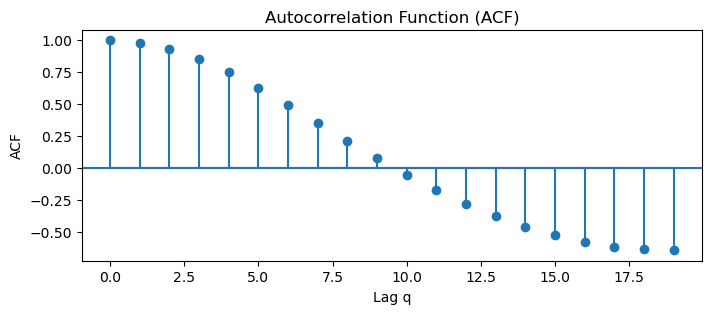

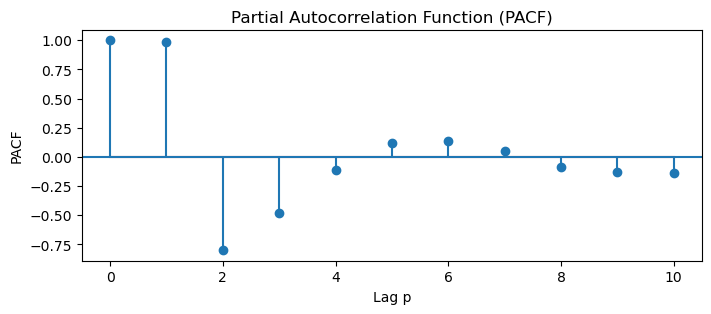

Studying RMSE for p=0, and different values of q.
q=0, p=0: The prediction of the validation set has an RMSE of 8.6250


/var/folders/77/t6fnxt9n4sj4t0n_387gtnxw0000gn/T/ipykernel_68542/3467716660.py:84: RuntimeWarning: overflow encountered in scalar multiply
  predicted_value += error*coefficient
/var/folders/77/t6fnxt9n4sj4t0n_387gtnxw0000gn/T/ipykernel_68542/3467716660.py:109: RuntimeWarning: overflow encountered in square
  errors_squared = np.array(errors)**2
/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/numpy/_core/_methods.py:173: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/numpy/_core/_methods.py:173: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


q=1, p=0: The prediction of the validation set has an RMSE of 4.6314


/var/folders/77/t6fnxt9n4sj4t0n_387gtnxw0000gn/T/ipykernel_68542/3467716660.py:84: RuntimeWarning: overflow encountered in scalar add
  predicted_value += error*coefficient
/var/folders/77/t6fnxt9n4sj4t0n_387gtnxw0000gn/T/ipykernel_68542/3467716660.py:84: RuntimeWarning: invalid value encountered in scalar add
  predicted_value += error*coefficient
/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/var/folders/77/t6fnxt9n4sj4t0n_387gtnxw0000gn/T/ipykernel_68542/3467716660.py:116: RuntimeWarning: invalid value encountered in scalar multiply
  term_3 = -((1)/(2*eps_variance))*np.sum(errors_squared)


q=2, p=0: The prediction of the validation set has an RMSE of 23.7155
q=3, p=0: The prediction of the validation set has an RMSE of 7.6012
q=4, p=0: The prediction of the validation set has an RMSE of 16.7203
Studying RMSE for p=1, and different values of q.
q=0, p=1: The prediction of the validation set has an RMSE of 1.6850
q=1, p=1: The prediction of the validation set has an RMSE of 1.3354


/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


q=2, p=1: The prediction of the validation set has an RMSE of 1.1415
q=3, p=1: The prediction of the validation set has an RMSE of 1.4443
q=4, p=1: The prediction of the validation set has an RMSE of 13.0992
Studying RMSE for p=2, and different values of q.
q=0, p=2: The prediction of the validation set has an RMSE of 0.9808
q=1, p=2: The prediction of the validation set has an RMSE of 0.9799
q=2, p=2: The prediction of the validation set has an RMSE of 1.1544
q=3, p=2: The prediction of the validation set has an RMSE of 24.9713
q=4, p=2: The prediction of the validation set has an RMSE of 17.5511
Studying RMSE for p=3, and different values of q.
q=0, p=3: The prediction of the validation set has an RMSE of 0.9350
q=1, p=3: The prediction of the validation set has an RMSE of 0.8779
q=2, p=3: The prediction of the validation set has an RMSE of 0.8802
q=3, p=3: The prediction of the validation set has an RMSE of 1.1327
q=4, p=3: The prediction of the validation set has an RMSE of 0.9169


In [8]:
def autocorrelation(real_values, k):
    "This function computes the autocorrelation for one value of k: ACF(k)"

    hat_y = statistics.mean(real_values)

    term_1 = 0
    for i in range(k, len(real_values)):
        term_1 += (real_values[i] - hat_y)*(real_values[i-k] - hat_y)

    term_2 = 0
    for i in range(0, len(real_values)):
        term_2 += (real_values[i] - hat_y)**2

    result = term_1/term_2
    return result

# ACF study
max_q = 20
q_values = range(0, max_q)
acf_values = []
for q_value in range(max_q):
    acf_value = autocorrelation(training_data, q_value)
    acf_values.append(acf_value)

plt.figure(figsize=(8,3))
plt.stem(q_values, acf_values)
plt.axhline(0)
plt.xlabel("Lag q")
plt.ylabel("ACF")
plt.title("Autocorrelation Function (ACF)")
plt.show()


# PACF study
max_p = 10
pacf_values = pacf(training_data, nlags=max_p, method="ywadjusted")
p_values = range(0,max_p+1)

plt.figure(figsize=(8,3))
plt.stem(p_values, pacf_values)
plt.axhline(0)
plt.xlabel("Lag p")
plt.ylabel("PACF")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()


# RMSE study
rmse_list = [[] for _ in range(4 + 1)]

for p in range(0,4+1):
    print(f'Studying RMSE for p={p}, and different values of q.')
    for q in range(0, 4+1):
        # We use scipy.optimize to find the coefficients
        res = scipy.optimize.minimize(function_for_minimizing, np.zeros(p+q+1), training_data, method = 'Nelder-Mead', tol=1e-4)
        coefficients = res['x']

        real_validation_values = np.array(validation_data)
        previous_values_coefficients = coefficients[:p]
        previous_errors_coefficients = coefficients[p:p+q]
        intercept = coefficients[p+q]
        #mu = np.mean(training_data)
        #intercept = mu * (1 - np.sum(previous_values_coefficients))
        errors_validation = np.array(calculate_whole_prediction_error(real_validation_values, previous_values_coefficients, previous_errors_coefficients, intercept, p, q))

        predicted_validation_values = real_validation_values - errors_validation

        rmse_validation = rmse(real_validation_values, predicted_validation_values)
        rmse_list[q].append(rmse_validation)
        print(f'q={q}, p={p}: The prediction of the validation set has an RMSE of {rmse_validation:.4f}')

Minimum RMSE value: 0.8779 for p=1, p=3


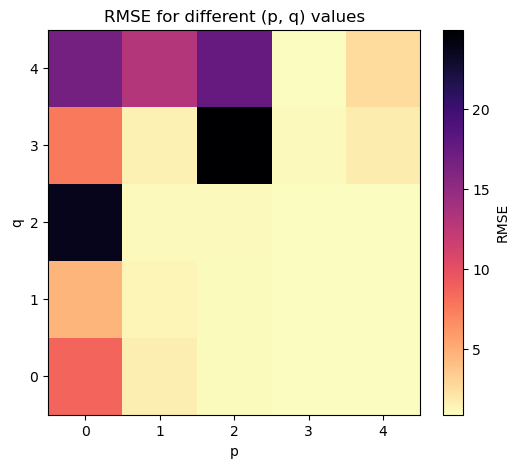

In [9]:
# Minimum RMSE
minimum_values = []
for p in range(len(rmse_list)):
    minimum_values.append(np.min(rmse_list[p]))

minimum_value = np.min(minimum_values)

minimum_value = float('inf')

for i, sublist in enumerate(rmse_list):
    min_in_sublist = np.min(sublist) # Minimum value in the sublist
    index_of_min_in_sublist = np.argmin(sublist) # Index of the minimum value in the list
    if min_in_sublist < minimum_value:
        minimum_value = min_in_sublist
        p_of_min_value = i
        q_of_min_value = index_of_min_in_sublist
        
print(f"Minimum RMSE value: {minimum_value:.4f} for p={p_of_min_value}, p={q_of_min_value}")


rmse_array = np.array(rmse_list)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    rmse_array,
    origin='lower',
    aspect='auto',
    cmap='magma_r'
)

ax.set_xlabel('p')
ax.set_ylabel('q')
ax.set_title('RMSE for different (p, q) values')
ax.set_xticks(range(4 + 1))
ax.set_yticks(range(4 + 1))

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('RMSE')
plt.show()

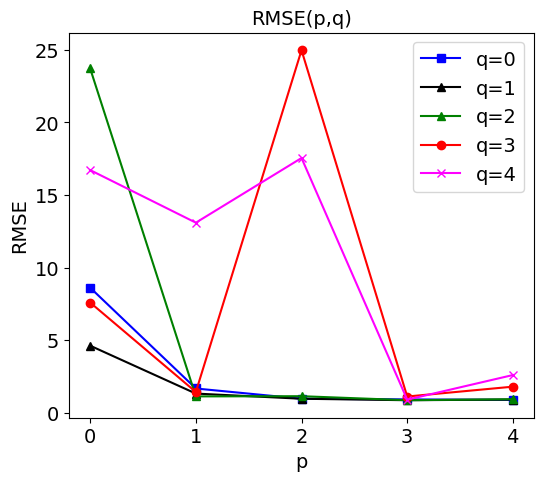

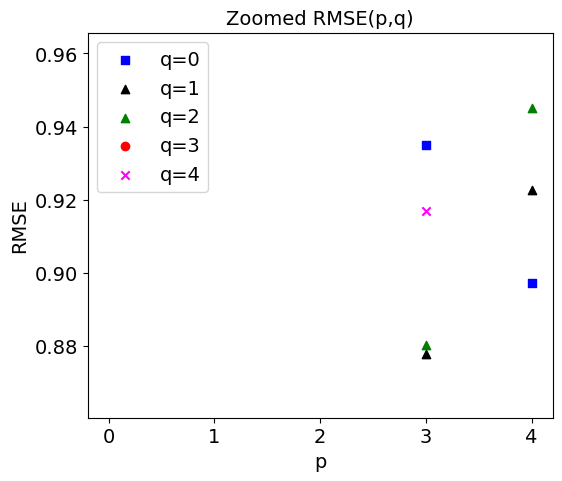

In [10]:
colors = ['blue', 'black', 'green', 'red', 'magenta']
markers = ['s', '^', '^', 'o', 'x']  # s=square, ^=triangle, o=circle, x=cross

p_values = np.arange(5)
q_values = np.arange(5)

fig, ax = plt.subplots(figsize=(6,5))

for q in q_values:
    ax.plot(p_values, rmse_list[q], marker=markers[q], color=colors[q], linestyle='-', label=f'q={q}')

ax.set_xlabel('p', fontsize=14)
ax.set_ylabel('RMSE', fontsize=14)
#ax.set_ylim([minimum_value,2])
ax.set_title('RMSE(p,q)', fontsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=14)
plt.show()

fig, ax = plt.subplots(figsize=(6,5))

for q in q_values:
    ax.scatter(p_values, rmse_list[q], marker=markers[q], color=colors[q], linestyle='-', label=f'q={q}')

ax.set_xlabel('p', fontsize=14)
ax.set_ylabel('RMSE', fontsize=14)
ax.set_ylim([minimum_value*0.98,minimum_value*1.1])
ax.set_title('Zoomed RMSE(p,q)', fontsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(loc='upper left', fontsize=14)
plt.show()

With the plots from the RMSE(p,q), we can see how $p=3$, $q=1$ give the best result (minimum RMSE for the validation data). We can also notice that the best results are obtained for $p=3,p=4$; i.e. values of $p$ close to the cutoff (at $p=3$).

# Exercise 1.4

In this exercise we train an LSTM and analyze its performance over a test set.

## Step 1: Training, window size and LSTM size
We must take into account that, as occurred with the ARMA model, the LSTM predicts based on the last $k$ values; the amount of $k$ values that the LSTM considers for prediction will be called 'window size'. Another important aspect is that the LSTM has a certain size. To determine what is the optimal window size and LSTM size, we will try different pairs of values and see for which pair we get the minimum validation loss.

For each pair (window size, LSTM size), we train the model during 100 epochs, and store the minimum validation loss. Repeating this process for all pairs (window size, LSTM size), we see which one yields the minimum validation loss, and we will consider that those parameters are the optimal ones.

## Step 2: Storing model with optimal parameters + minimal val. loss
Once we have obtained the best parameters, we train the model with them and we now use a checkpoint to ensure that we store the best model; i.e. the model at the epoch with minimum validation loss. 
If we did not do this, and instead we kept the last model (after the 100 epochs), we could end up with a model with a worse performance than the one that made us choose the pair (window size, LSTM size); i.e. a model worse than the best we can achieve with this pair of parameters.

## Checkpoint vs Early stopping
Although we could use early stopping and stop the training if the model does not get better after a certain number of epochs, it could happen that for some epochs, the model is not achieving better results, but afterwards it does. To avoid stopping the training before its global minimum validation loss is reached, it is safer to use a checkpoint instead.

## Step 3: Test set (Plot + RMSE)
Finally, we study how accurately does the model predict the test data measuring the RMSE.

## Step 1:

In [11]:
# LSTM
def make_windows(series, window_size):
    "This function separates a time series in windows, so the LSTM can work"

    x_inputs, y_outputs = [], [] # x_inputs will store inputs, y_outputs will store outputs

    # idex 'i' will go over the first value of each window. Starting in 0, finishing in len(series)-window_size
    for i in range(len(series) - window_size):

        x_inputs.append(series[i:i+window_size])
        y_outputs.append(series[i+window_size])

    return np.array(x_inputs), np.array(y_outputs)



number_of_epochs = 100
window_sizes = [5, 10, 20, 30, 40]
lstm_sizes = [8,16, 32, 64]
"""window_sizes = [20, 30, 40]
lstm_sizes = [32, 64, 80]"""
results = {}

number_of_studies = len(window_sizes) * len(lstm_sizes)
i = 0

for window_size in window_sizes:
    
    x_training, y_training = make_windows(training_data, window_size)
    x_validation, y_validation = make_windows(validation_data, window_size)

    x_training = x_training[..., np.newaxis]
    x_validation = x_validation[..., np.newaxis]

    for lstm_size in lstm_sizes:

        # We use lstm_size neurons, activation function of tanh and 1 layer (Dense(1)). The 1 in input shape indicates the feature
        lstm = Sequential([LSTM(lstm_size, activation = 'tanh', input_shape = (window_size, 1)), Dense(1)])

        # We use the Adam optimizer and the MSE loss function
        lstm.compile(optimizer = 'adam', loss = 'mse')

        history = lstm.fit(x_training, y_training, validation_data = (x_validation, y_validation), epochs = number_of_epochs, batch_size = 32, verbose = 0)

        # I store the minimum (we avoid overfitting)
        results[window_size, lstm_size] = min(history.history['val_loss'])

        i += 1
        print(f' \n Window size {window_size} with LSTM size {lstm_size} studied. Minimum validation loss {results[window_size, lstm_size]:.3f}. {i}/{number_of_studies} analysis completed \n')


best_window_size, best_lstm_size = min(results, key=results.get)

filename = 'Assignment_1/store_parameters.txt'
with open(filename, 'w') as file_object:
    file_object.write(f'{best_window_size} \n')
    file_object.write(f'{best_lstm_size} \n')

print(f'Best window size: {best_window_size}, best LSTM size: {best_lstm_size}, Validation loss: {results[best_window_size, best_lstm_size]}')


/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 
 Window size 5 with LSTM size 8 studied. Minimum validation loss 0.356. 1/20 analysis completed 

 
 Window size 5 with LSTM size 16 studied. Minimum validation loss 0.339. 2/20 analysis completed 

 
 Window size 5 with LSTM size 32 studied. Minimum validation loss 0.325. 3/20 analysis completed 

 
 Window size 5 with LSTM size 64 studied. Minimum validation loss 0.324. 4/20 analysis completed 

 
 Window size 10 with LSTM size 8 studied. Minimum validation loss 0.260. 5/20 analysis completed 

 
 Window size 10 with LSTM size 16 studied. Minimum validation loss 0.259. 6/20 analysis completed 

 
 Window size 10 with LSTM size 32 studied. Minimum validation loss 0.252. 7/20 analysis completed 

 
 Window size 10 with LSTM size 64 studied. Minimum validation loss 0.250. 8/20 analysis completed 

 
 Window size 20 with LSTM size 8 studied. Minimum validation loss 0.258. 9/20 analysis completed 

 
 Window size 20 with LSTM size 16 studied. Minimum validation loss 0.228. 10/20 analysi

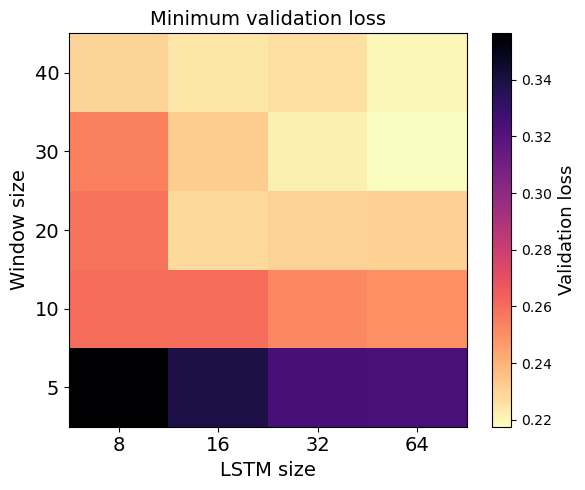

In [12]:
# Plot of validation loss as a function of window size and lstm size
val_loss_array = np.zeros((len(window_sizes), len(lstm_sizes)))

for i, window_size in enumerate(window_sizes):
    for j, lstm_size in enumerate(lstm_sizes):
        val_loss_array[i, j] = results[(window_size, lstm_size)]

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    val_loss_array,
    origin='lower',
    aspect='auto',
    cmap='magma_r'
)

# Axis labels and ticks
ax.set_xlabel('LSTM size', fontsize = 14)
ax.set_ylabel('Window size', fontsize = 14)
ax.set_title('Minimum validation loss', fontsize = 14)

ax.set_xticks(range(len(lstm_sizes)))
ax.set_xticklabels(lstm_sizes, fontsize = 14)

ax.set_yticks(range(len(window_sizes)))
ax.set_yticklabels(window_sizes, fontsize = 14)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Validation loss', fontsize = 13)

plt.tight_layout()
plt.show()

## Step 2:

In [13]:
# Storing parameters of best LSTM
filename = 'Assignment_1/store_parameters.txt'
with open(filename, 'r') as file_object:
    lines = file_object.readlines()

best_window_size = int(lines[0].strip())
best_lstm_size = int(lines[1].strip())

# Setting LSTM with best performing parameters
lstm = Sequential([LSTM(best_lstm_size, activation = 'tanh', input_shape = (best_window_size, 1)), Dense(1)])
lstm.compile(optimizer = 'adam', loss = 'mse')


def make_windows(series, window_size):
    "This function separates a time series in windows, so the LSTM can work"

    x_inputs, y_outputs = [], [] # x_inputs will store inputs, y_outputs will store outputs

    # idex 'i' will go over the first value of each window. Starting in 0, finishing in len(series)-window_size
    for i in range(len(series) - window_size):

        x_inputs.append(series[i:i+window_size])
        y_outputs.append(series[i+window_size])

    return np.array(x_inputs), np.array(y_outputs)


# Training data formatted with the window size
x_training, y_training = make_windows(training_data, best_window_size)
x_training = x_training[..., np.newaxis]

x_validation, y_validation = make_windows(validation_data, best_window_size)
x_validation = x_validation[..., np.newaxis]

"""# Test data formatted with the window size
x_test, y_test = make_windows(test_data, best_window_size)
x_test = x_test[..., np.newaxis]"""

# Training
number_of_epochs = 100
# We want to keep the LSTM from the epoch where the minimum validation error is achieved. We use checkpoint for that.
# We could use early stopping, but since times are not that long, it is better to use a checkpoint to ensure the minimization of the val_loss.
checkpoint = ModelCheckpoint(filepath='Assignment_1/best_model.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)
lstm.fit(x_training, y_training, validation_data = (x_validation, y_validation), epochs = number_of_epochs, batch_size = 32, callbacks=[checkpoint], verbose = 1)

Epoch 1/100


/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


300/312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 343.4289
Epoch 1: val_loss improved from None to 39.98306, saving model to Assignment_1/best_model.keras

Epoch 1: finished saving model to Assignment_1/best_model.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 187.8390 - val_loss: 39.9831
Epoch 2/100
296/312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.6074
Epoch 2: val_loss improved from 39.98306 to 8.36894, saving model to Assignment_1/best_model.keras

Epoch 2: finished saving model to Assignment_1/best_model.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 19.1265 - val_loss: 8.3689
Epoch 3/100
302/312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3243
Epoch 3: val_loss improved from 8.36894 to 2.67395, saving model to Assignment_1/best_model.keras

Epoch 3: finished saving model to Assignment_1/best_model.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.8199 - val_loss: 2.6739
Epoch 4/100
306/312 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0791
Epoch 4: val_loss im

## Step 3:

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


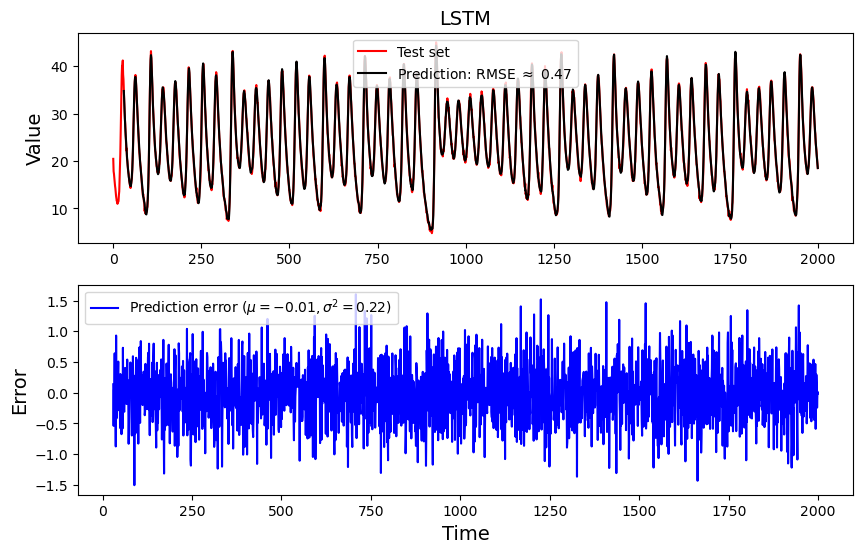

LSTM (window_size=30, lstm_size=64): Test set prediction RMSE=0.4701.


/var/folders/77/t6fnxt9n4sj4t0n_387gtnxw0000gn/T/ipykernel_68542/3467716660.py:109: RuntimeWarning: overflow encountered in square
  errors_squared = np.array(errors)**2
/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/77/t6fnxt9n4sj4t0n_387gtnxw0000gn/T/ipykernel_68542/3467716660.py:116: RuntimeWarning: invalid value encountered in scalar multiply
  term_3 = -((1)/(2*eps_variance))*np.sum(errors_squared)


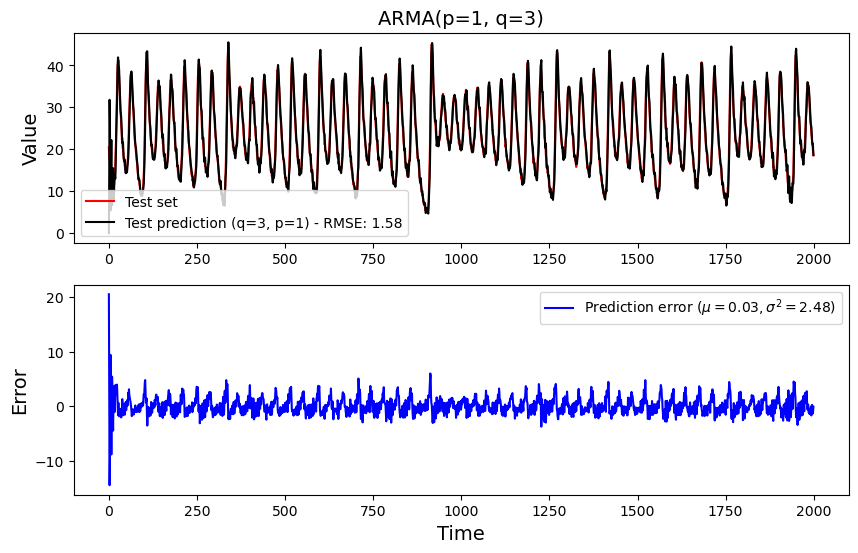

ARMA(p=1,q=3): Test set prediction RMSE=1.5750


In [14]:
# Read best performing parameters so that we can convert test set to LSTM readable data
filename = 'Assignment_1/store_parameters.txt'
with open(filename, 'r') as file_object:
    lines = file_object.readlines()

best_window_size = int(lines[0].strip())

def make_windows(series, window_size):
    "This function separates a time series in windows, so the LSTM can work"

    x_inputs, y_outputs = [], [] # x_inputs will store inputs, y_outputs will store outputs

    # idex 'i' will go over the first value of each window. Starting in 0, finishing in len(series)-window_size
    for i in range(len(series) - window_size):

        x_inputs.append(series[i:i+window_size])
        y_outputs.append(series[i+window_size])

    return np.array(x_inputs), np.array(y_outputs)


# Test data formatted with the window size
x_test, y_test = make_windows(test_data, best_window_size)
x_test = x_test[..., np.newaxis]

lstm = load_model('Assignment_1/best_model.keras')

# Predicting
y_pred = lstm.predict(x_test)

# Calculating RMSE
def rmse(real_values, predicted_values):
    "This function calculates the RMSE"
    number_of_values = len(real_values)
    sum_term = 0
    for i in range(number_of_values):
        real_value = real_values[i]
        predicted_value = predicted_values[i]
        new_term = (predicted_value - real_value)**2
        sum_term += new_term

    rmse_value = math.sqrt(sum_term/number_of_values)

    return rmse_value


y_pred_2 = []
for i in range(len(y_pred)):
    y_pred_2.append(y_pred[i][0])
y_pred = np.array(y_pred_2)

test_data = np.array(test_data)
rmse_test = rmse(test_data[best_window_size:], y_pred)



# Plotting
label_size = 14
fig, axes = plt.subplots(2,1,figsize=(10,6))
axes[0].plot(test_data, 'r', label = 'Test set')
axes[0].plot(range(best_window_size, len(test_data)), y_pred, 'k', label=rf'Prediction: RMSE $\approx$ {rmse_test:.2f}') # y_pred does not have the same length as test_data
axes[0].set_ylabel('Value', fontsize = label_size)
axes[0].set_title('LSTM', fontsize = label_size)
axes[0].legend()

len_difference = len(test_data) - len(y_pred)
errors_test=test_data[len_difference:]-y_pred
mean_error = np.mean(errors_test)
var_error = np.var(errors_test)

axes[1].plot(time_in_test_data[len_difference:], errors_test, color='b', label = rf'Prediction error ($\mu={mean_error:.2f}, \sigma^2={var_error:.2f}$)')
axes[1].set_ylabel("Error", fontsize = label_size)
axes[1].set_xlabel("Time", fontsize = label_size)
#axes[1].set_title(f"ARMA(p={p_of_min_value}, q={q_of_min_value})")
axes[1].legend()
plt.show()
print(f'LSTM (window_size={best_window_size}, lstm_size={best_lstm_size}): Test set prediction RMSE={rmse_test:.4f}.')






# Plot ARMA prediction with test set
p = p_of_min_value
q = q_of_min_value

# We use scipy.optimize to find the coefficients
res = scipy.optimize.minimize(function_for_minimizing, np.zeros(p+q+1), training_data, method = 'Nelder-Mead', tol=1e-4)
coefficients = res['x']

real_test_values = np.array(test_data)
previous_values_coefficients = coefficients[:p]
previous_errors_coefficients = coefficients[p:p+q]
intercept = coefficients[p+q]
#mu = np.mean(training_data)
#intercept = mu * (1 - np.sum(previous_values_coefficients))
errors_test = np.array(calculate_whole_prediction_error(real_test_values, previous_values_coefficients, previous_errors_coefficients, intercept, p, q))

predicted_test_values = real_test_values - errors_test

rmse_test = rmse(real_test_values, predicted_test_values)

fig, axes = plt.subplots(2,1,figsize=(10,6))
axes[0].plot(time_in_test_data, test_data, color='r', label = 'Test set')
axes[0].plot(time_in_test_data, predicted_test_values, color='k', label = f'Test prediction (q={q}, p={p}) - RMSE: {rmse_test:.2f}')
axes[0].set_ylabel("Value", fontsize = label_size)
axes[0].set_title(f"ARMA(p={p_of_min_value}, q={q_of_min_value})", fontsize = label_size)
axes[0].legend()

mean_error = np.mean(errors_test)
var_error = np.var(errors_test)

axes[1].plot(time_in_test_data, errors_test, color='b', label = rf'Prediction error ($\mu={mean_error:.2f}, \sigma^2={var_error:.2f}$)')
axes[1].set_ylabel("Error", fontsize = label_size)
axes[1].set_xlabel("Time", fontsize = label_size)
#axes[1].set_title(f"ARMA(p={p_of_min_value}, q={q_of_min_value})")
axes[1].legend()
plt.show()

print(f'ARMA(p={p_of_min_value},q={q_of_min_value}): Test set prediction RMSE={rmse_test:.4f}')

# Exercise 1.5

Here, we present the values of the coefficients from our ARMA model. For an interpretation of the results, see next text cell.

In [15]:
print("\nEstimated ARMA coefficients:\n")

# AR coefficients
for i, value in enumerate(previous_values_coefficients, start=1):
    print(f"phi_{i} (y_{{t-{i}}}) = {value:.2f}")

# MA coefficients
for i, value in enumerate(previous_errors_coefficients, start=1):
    print(f"theta_{i} (eps_{{t-{i}}}) = {value:.2f}")



Estimated ARMA coefficients:

phi_1 (y_{t-1}) = 1.00
theta_1 (eps_{t-1}) = 0.04
theta_2 (eps_{t-2}) = 0.75
theta_3 (eps_{t-3}) = -0.33



## Analyzing the ARMA model

- **Value parameters:** We can see that $\phi_{1}=1$. This sequence implies that, when thinking about the AR part of the model, the most determining value for the linear prediction is the one that occurred one time steps ago; i.e. $y_{t-1}$. Also, given that $\phi_{1}$ is positive, the term $y_{t-1}$ contributes positively; i.e. a positive value of $y_{t-1}$ will push $y_{t}$ to be positive; and negative values of $y_{t-1}$ will push $y_{t}$ to be negative.

- **Error parameters:** We can see that $|\theta_{2}|>|\theta_{3}|>|\theta_{1}|$. This sequence indicates that, when taking into account what errors were made in the previous time steps, the most important one is the error that we made two time steps before, $\epsilon_{t-2}$. The parameters $\theta_{1}$ and $\theta_{2}$ being positive indicate that in steps $y_{t-1}$ and $y_{t-2}$, if the predictions were above the real value ($\epsilon_{t-1}>0$, $\epsilon_{t-2}>0$), then we should aim for a higher value for the current state ($\theta_{1}\epsilon_{t-1}>0$, $\theta_{3}\epsilon_{t-3}>0$); if they were below the real value ($\epsilon_{t-1}<0$, $\epsilon_{t-2}<0$), then they contribute negatively ($\theta_{1}\epsilon_{t-1}<0$, $\theta_{2}\epsilon_{t-2}<0$). 
However, the prediction error for $y_{t-3}$ works the other way around since $\theta_{3}<0$. Here, $\epsilon_{t-3}>0$ contributes negatively: $\theta_{3}\epsilon_{t-3}<0$, and $\epsilon_{t-3}<0$ contributes positively: $\theta_{3}\epsilon_{t-3}>0$. Therefore, there exists negative propagation in this case. This negative coefficient indicates that an overprediction three steps ago tends to be compensated by a decrease in the current prediction. With this, we prevent error accumulation.


## Comparing LSTM and ARMA model
Studying how does the ARMA and the LSTM predict, one can extract some conclusions.
- Interpretability: If interpretability is key for the study, one should use the ARMA model, since the parameter estimations already provide useful information about the data set. Meanwhile, the LSTM provides little interpretability, since it is a black-box model that takes inputs from the time series' previous values and outputs a prediction for the next value, completely lacking interpretability.

- $\text{RMSE}$: If minimal error is the most important aspect of the study, the LSTM black-box model should be applied, since $\text{RMSE}_{LSTM}\approx0.3\cdot \text{RMSE}_{ARMA}$. 
All in all, the choice between models depends on the goal of the study. The use of an LSTM in this case implies a complete lost of the interpretability that we get for the ARMA model, in return for a reduced $\text{RMSE}$. Note that, although $\text{RMSE}_{LSTM}\approx0.3\cdot \text{RMSE}_{ARMA}$, the order of magnitude from these RMSE is really small when compared to the test values, so, although the accuracy might be of extreme importance for a study, maybe the complete lost of interpretability is not worth the RMSE reduction.
